# Úkol 5


In [1]:
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

def generate_components(K, seed=42):
    rng = np.random.default_rng(seed)
    components = []
    for _ in range(K):
        variants = []
        for _ in range(3):
            price  = int(rng.integers(5, 31))
            energy = int(rng.integers(3, 26))
            perf   = int(rng.integers(1, 51))
            variants.append((price, energy, perf))
        components.append(variants)
    return components

def limits(K):
    return 20 * K, 15 * K

def evaluate(sol, components):
    price  = sum(components[k][v][0] for k, v in enumerate(sol))
    energy = sum(components[k][v][1] for k, v in enumerate(sol))
    perf   = sum(components[k][v][2] for k, v in enumerate(sol))
    return price, energy, perf

def is_valid(price, energy, W1, W2):
    return price <= W1 and energy <= W2

def brute_force(components, K):
    W1, W2 = limits(K)
    best_perf, best_sol = -1, None
    total = 0
    valid = 0
    for combo in itertools.product(range(3), repeat=K):
        total += 1
        price  = sum(components[k][v][0] for k, v in enumerate(combo))
        energy = sum(components[k][v][1] for k, v in enumerate(combo))
        if is_valid(price, energy, W1, W2):
            valid += 1
            perf = sum(components[k][v][2] for k, v in enumerate(combo))
            if perf > best_perf:
                best_perf, best_sol = perf, combo
    return best_sol, best_perf, total, valid

results_bf = {}
for K in [5, 8, 10]:
    components = generate_components(K)
    W1, W2 = limits(K)
    t0 = time.perf_counter()
    sol, perf, total, valid = brute_force(components, K)
    elapsed = time.perf_counter() - t0
    invalid = total - valid
    results_bf[K] = {
        "time": elapsed, "perf": perf, "sol": sol,
        "components": components,
        "total": total, "valid": valid, "invalid": invalid
    }
    display(HTML(
        f"<b>K={K}</b> | W<sub>1</sub>={W1}, W<sub>2</sub>={W2} | "
        f"kombinací = 3<sup>{K}</sup> = {total:,} | "
        f"validních = {valid:,} | nevalidních = {invalid:,} ({invalid/total*100:.1f}%) | "
        f"nejlepší výkon = <b>{perf}</b> | čas = {elapsed:.4f} s"
    ))


=== I. Brute Force ===

   K |  Kombinací |  Validních |  Nevalidních |  % nevalidní |    Čas (s) |   Výkon
--------------------------------------------------------------------------------------
   5 |        243 |         97 |          146 |        60.1% |     0.0004 |     200
   8 |      6,561 |      2,103 |        4,458 |        67.9% |     0.0112 |     297
  10 |     59,049 |     26,145 |       32,904 |        55.7% |     0.1223 |     387


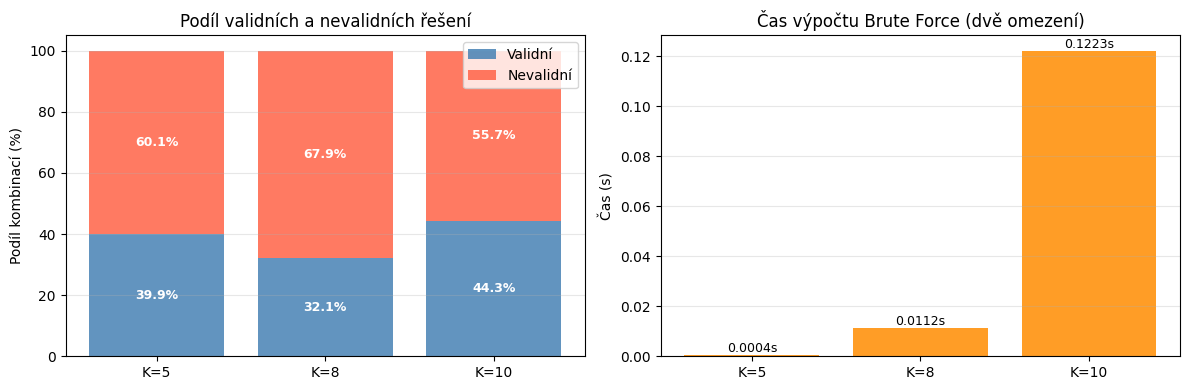

In [2]:
print("=== I. Brute Force ===\n")

print(f"{'K':>4} | {'Kombinací':>10} | {'Validních':>10} | {'Nevalidních':>12} | "
      f"{'% nevalidní':>12} | {'Čas (s)':>10} | {'Výkon':>7}")
print("-" * 86)
for K, r in results_bf.items():
    print(f"{K:>4} | {r['total']:>10,} | {r['valid']:>10,} | {r['invalid']:>12,} | "
          f"{r['invalid']/r['total']*100:>11.1f}% | {r['time']:>10.4f} | {r['perf']:>7}")

K_list      = list(results_bf.keys())
valid_pct   = [results_bf[K]["valid"]   / results_bf[K]["total"] * 100 for K in K_list]
invalid_pct = [results_bf[K]["invalid"] / results_bf[K]["total"] * 100 for K in K_list]
times       = [results_bf[K]["time"] for K in K_list]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(K_list))

axes[0].bar(x, valid_pct,   label="Validní",   color="steelblue", alpha=0.85)
axes[0].bar(x, invalid_pct, bottom=valid_pct,  label="Nevalidní", color="tomato",    alpha=0.85)
for i, (vp, ip) in enumerate(zip(valid_pct, invalid_pct)):
    axes[0].text(i, vp/2,      f"{vp:.1f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    axes[0].text(i, vp + ip/2, f"{ip:.1f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"K={k}" for k in K_list])
axes[0].set_ylabel("Podíl kombinací (%)"); axes[0].set_title("Podíl validních a nevalidních řešení")
axes[0].legend(); axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(x, times, color="darkorange", alpha=0.85)
for i, t in enumerate(times):
    axes[1].text(i, t + max(times)*0.01, f"{t:.4f}s", ha="center", fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels([f"K={k}" for k in K_list])
axes[1].set_ylabel("Čas (s)"); axes[1].set_title("Čas výpočtu Brute Force (dvě omezení)")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [3]:
print("=== II. Surogátní model ===\n")

def random_valid_sol(components, K, rng):
    W1, W2 = limits(K)
    for _ in range(50000):
        sol = tuple(int(rng.integers(0, 3)) for _ in range(K))
        price  = sum(components[k][v][0] for k, v in enumerate(sol))
        energy = sum(components[k][v][1] for k, v in enumerate(sol))
        if price <= W1 and energy <= W2:
            return sol
    return tuple(
        int(np.argmin([components[k][v][0] + components[k][v][1] for v in range(3)]))
        for k in range(K)
    )

def sample_valid_solutions(components, K, n=100, seed=42):
    rng = np.random.default_rng(seed)
    samples, seen = [], set()
    max_attempts = max(n * 500, 20000)
    attempts = 0
    while len(samples) < n and attempts < max_attempts:
        attempts += 1
        sol = random_valid_sol(components, K, rng)
        if sol not in seen:
            seen.add(sol)
            price, energy, perf = evaluate(sol, components)
            samples.append((sol, perf))
    if len(samples) < n:
        print(f"  [Info] K={K}: dostupných pouze {len(samples)} unikatních validních "
              f"řešení (požadováno {n}); použito všech {len(samples)}")
    return samples

def build_surrogate_original(samples, K):
    total = [[0.0]*3 for _ in range(K)]
    cnt   = [[0]  *3 for _ in range(K)]
    for sol, perf in samples:
        for k, v in enumerate(sol):
            total[k][v] += perf
            cnt[k][v]   += 1
    gm = np.mean([p for _, p in samples])
    return [[total[k][v]/cnt[k][v] if cnt[k][v]>0 else gm for v in range(3)] for k in range(K)]

def greedy_by_surrogate(components, K, surrogate):
    return tuple(int(np.argmax(surrogate[k])) for k in range(K))

K_surr   = 8
comp_s   = results_bf[K_surr]["components"]
W1s, W2s = limits(K_surr)

samples_s = sample_valid_solutions(comp_s, K_surr, n=100, seed=42)

print("Průměrný výkon variant (prvních 5 komponent):")
surrogate_s = build_surrogate_original(samples_s, K_surr)
print(f"  {'k':>3} | {'var 0':>8} | {'var 1':>8} | {'var 2':>8}")
print("  " + "-"*38)
for k in range(min(5, K_surr)):
    print(f"  {k:>3} | {surrogate_s[k][0]:>8.1f} | {surrogate_s[k][1]:>8.1f} | {surrogate_s[k][2]:>8.1f}")

surr_sol_s        = greedy_by_surrogate(comp_s, K_surr, surrogate_s)
sp, se, sperf     = evaluate(surr_sol_s, comp_s)
s_valid           = is_valid(sp, se, W1s, W2s)
bf_perf_s         = results_bf[K_surr]["perf"]

print("\nSkutečný výkon a ověření omezení:")
print(f"{'Metoda':<35} | {'Výkon':>7} | {'Cena':>6} | {'Energie':>8} | {'Validní':>8}")
print("-"*76)
print(f"{'Brute Force (optimum)':<35} | {bf_perf_s:>7} | {'--':>6} | {'--':>8} | {'ano':>8}")
print(f"{'Surogátní greedy model (původní)':<35} | {sperf:>7} | {sp:>6} | {se:>8} | {str(s_valid):>8}")
print(f"\nLimity: W1={W1s}, W2={W2s}")
if s_valid:
    gap = (bf_perf_s - sperf) / bf_perf_s * 100
    print(f"Mezera surogátní model vs. optimum: {gap:.1f} %")
else:
    print(f"Surogátní model vrátil NEVALIDNÍ řešení! "
          f"Překročení ceny: {max(0,sp-W1s)}, energie: {max(0,se-W2s)}")


=== II. Surogátní model ===

Průměrný výkon variant (prvních 5 komponent):
    k |    var 0 |    var 1 |    var 2
  --------------------------------------
    0 |    200.2 |    222.1 |    184.6
    1 |    218.5 |    205.5 |    169.7
    2 |    201.2 |    204.6 |    200.5
    3 |    222.0 |    195.0 |    198.5
    4 |    187.5 |    217.3 |    186.8

Skutečný výkon a ověření omezení:
Metoda                              |   Výkon |   Cena |  Energie |  Validní
----------------------------------------------------------------------------
Brute Force (optimum)               |     297 |     -- |       -- |      ano
Surogátní greedy model (původní)    |     297 |    153 |      100 |     True

Limity: W1=160, W2=120
Mezera surogátní model vs. optimum: 0.0 %


In [4]:
print("=== III. Selhání surogátního modelu ===\n")

def generate_components_biased(K, seed=77):
    rng = np.random.default_rng(seed)
    components = []
    for _ in range(K):
        variants = [
            (int(rng.integers(30, 51)), int(rng.integers(25, 51)), int(rng.integers(35, 51))),
            (int(rng.integers(1,  11)), int(rng.integers(1,  11)), int(rng.integers(1,  16))),
            (int(rng.integers(10, 25)), int(rng.integers(8,  20)), int(rng.integers(15, 35))),
        ]
        components.append(variants)
    return components

K_fail   = 8
comp_f   = generate_components_biased(K_fail)
W1f, W2f = limits(K_fail)

_, bf_fail, total_f, valid_f = brute_force(comp_f, K_fail)
invalid_f = total_f - valid_f
print(f"Biased dataset: validních = {valid_f:,}/{total_f:,} ({valid_f/total_f*100:.2f}%)")
print(f"Brute-force optimum: výkon = {bf_fail}\n")

samples_f   = sample_valid_solutions(comp_f, K_fail, n=100, seed=42)
surrogate_f = build_surrogate_original(samples_f, K_fail)
surr_sol_f  = greedy_by_surrogate(comp_f, K_fail, surrogate_f)
sf_p, sf_e, sf_perf = evaluate(surr_sol_f, comp_f)
sf_valid    = is_valid(sf_p, sf_e, W1f, W2f)

print("Vybírá surogátní model vysoko-nakladné varianty?")
print(f"{'k':>3} | {'v*':>3} | {'surogát':>13} | {'cena':>5} | {'energie':>7} | {'výkon':>6} | poznámka")
print("-"*72)
for k in range(K_fail):
    v_best = int(np.argmax(surrogate_f[k]))
    pr, en, pf = comp_f[k][v_best]
    flag = " <-- vysoké náklady!" if pr > W1f/K_fail or en > W2f/K_fail else ""
    print(f"{k:>3} | {v_best:>3} | {surrogate_f[k][v_best]:>13.1f} | {pr:>5} | {en:>7} | {pf:>6}{flag}")

print(f"\nSurogátní greedy model: výkon={sf_perf}, cena={sf_p} (limit {W1f}), "
      f"energie={sf_e} (limit {W2f}), validní={sf_valid}")
if not sf_valid:
    print(f"  --> Překročení ceny: {max(0,sf_p-W1f)},  překročení energie: {max(0,sf_e-W2f)}")

print("\nProč surogátní model selhal?")
print("Původní surogátní model přiřadí vysoké průměrné hodnoty variantě 0, protože vzorky kde se vyskytovala, mají celkem vyšší výkon.")
print("Surogátní model neví nic o ceně/spotřebě konkrétní varianty, ignoruje tedy omezení.")
print("Greedy model tak vybere výkonnou, ale drahou/energeticky náročnou variantu = nevalidní řešení.")


=== III. Selhání surogátního modelu ===

Biased dataset: validních = 1,161/6,561 (17.70%)
Brute-force optimum: výkon = 203

Vybírá surogátní model vysoko-nakladné varianty?
  k |  v* |       surogát |  cena | energie |  výkon | poznámka
------------------------------------------------------------------------
  0 |   2 |         146.6 |    22 |      12 |     34 <-- vysoké náklady!
  1 |   0 |         144.7 |    36 |      34 |     41 <-- vysoké náklady!
  2 |   2 |         138.8 |    24 |       9 |     30 <-- vysoké náklady!
  3 |   0 |         141.2 |    37 |      42 |     48 <-- vysoké náklady!
  4 |   2 |         142.2 |    13 |      12 |     21
  5 |   1 |         132.8 |     6 |       2 |      9
  6 |   0 |         144.0 |    50 |      35 |     42 <-- vysoké náklady!
  7 |   0 |         146.0 |    30 |      42 |     47 <-- vysoké náklady!

Surogátní greedy model: výkon=272, cena=218 (limit 160), energie=188 (limit 120), validní=False
  --> Překročení ceny: 58,  překročení energie: 6

In [5]:
print("=== IV. Vylepšení suroggátního modelu ===\n")

def build_surrogate_improved(samples, K, components):
    metric = [[0.0]*3 for _ in range(K)]
    cnt    = [[0]  *3 for _ in range(K)]
    for sol, perf in samples:
        for k, v in enumerate(sol):
            price, energy, _ = components[k][v]
            m = perf / (price + energy) if (price + energy) > 0 else 0.0
            metric[k][v] += m
            cnt[k][v]    += 1
    return [[metric[k][v]/cnt[k][v] if cnt[k][v]>0 else 1.0 for v in range(3)] for k in range(K)]

def greedy_surrogate_feasible(components, K, surrogate):
    W1, W2 = limits(K)
    sol    = [int(np.argmax(surrogate[k])) for k in range(K)]
    price  = sum(components[k][sol[k]][0] for k in range(K))
    energy = sum(components[k][sol[k]][1] for k in range(K))
    for _ in range(K * K + K):
        if price <= W1 and energy <= W2:
            break
        best_gain, best_k, best_v = -1, -1, -1
        for k in range(K):
            cur_p, cur_e, _ = components[k][sol[k]]
            for v in range(3):
                if v == sol[k]:
                    continue
                p, e, _ = components[k][v]
                gain = (max(0, cur_p - p) * int(price  > W1)
                      + max(0, cur_e - e) * int(energy > W2))
                if gain > best_gain:
                    best_gain, best_k, best_v = gain, k, v
        if best_k == -1 or best_gain == 0:
            break
        old_p, old_e, _ = components[best_k][sol[best_k]]
        new_p, new_e, _ = components[best_k][best_v]
        price  = price  - old_p + new_p
        energy = energy - old_e + new_e
        sol[best_k] = best_v
    if price > W1 or energy > W2:
        sol = [int(np.argmin([components[k][v][0]+components[k][v][1] for v in range(3)])) for k in range(K)]
    return tuple(sol)

print("Nová metrika: výkon/(cena + spotřeba)\n")

for comp_imp, label, bf_imp in [
    (results_bf[8]["components"], "normalní dataset (K=8)", results_bf[8]["perf"]),
    (comp_f,                      "biased dataset  (K=8)", bf_fail),
]:
    K_imp    = 8
    W1i, W2i = limits(K_imp)
    smpls    = sample_valid_solutions(comp_imp, K_imp, n=100, seed=42)

    surr_o  = build_surrogate_original(smpls, K_imp)
    surr_i  = build_surrogate_improved(smpls, K_imp, comp_imp)

    sol_o   = greedy_by_surrogate(comp_imp, K_imp, surr_o)
    sol_i   = greedy_surrogate_feasible(comp_imp, K_imp, surr_i)

    po, eo, pfo = evaluate(sol_o, comp_imp)
    pi, ei, pfi = evaluate(sol_i, comp_imp)
    vo = is_valid(po, eo, W1i, W2i)
    vi = is_valid(pi, ei, W1i, W2i)

    gap_o = f"{(bf_imp-pfo)/bf_imp*100:.1f} %" if vo else "NEVALIDNÍ"
    gap_i = f"{(bf_imp-pfi)/bf_imp*100:.1f} %" if vi else "NEVALIDNÍ"

    print(f"--- {label} ---")
    print(f"{'Metoda':<40} | {'Výkon':>7} | {'Cena':>6} | {'Energie':>8} | {'Validní':>8} | {'Mezera':>10}")
    print("-"*94)
    print(f"{'BF optimum':<40} | {bf_imp:>7} | {'--':>6} | {'--':>8} | {'ano':>8} | {'--':>10}")
    print(f"{'Surogátní původní (průměrný výkon)':<40} | {pfo:>7} | {po:>6} | {eo:>8} | {str(vo):>8} | {gap_o:>10}")
    print(f"{'Surogátní vylepšený (výkon/cena+energie)':<40} | {pfi:>7} | {pi:>6} | {ei:>8} | {str(vi):>8} | {gap_i:>10}")
    print()


=== IV. Vylepšení suroggátního modelu ===

Nová metrika: výkon/(cena + spotřeba)

--- normalní dataset (K=8) ---
Metoda                                   |   Výkon |   Cena |  Energie |  Validní |     Mezera
----------------------------------------------------------------------------------------------
BF optimum                               |     297 |     -- |       -- |      ano |         --
Surogátní původní (průměrný výkon)       |     297 |    153 |      100 |     True |      0.0 %
Surogátní vylepšený (výkon/cena+energie) |     238 |    129 |       74 |     True |     19.9 %

--- biased dataset  (K=8) ---
Metoda                                   |   Výkon |   Cena |  Energie |  Validní |     Mezera
----------------------------------------------------------------------------------------------
BF optimum                               |     203 |     -- |       -- |      ano |         --
Surogátní původní (průměrný výkon)       |     272 |    218 |      188 |    False |  NEVALIDNÍ
S

=== V. Srovnání přístupů ===

  [Info] K=5: dostupných pouze 97 unikatních validních řešení (požadováno 100); použito všech 97
  K |  BF výkon |   BF čas | Sur. původní |  Validní |   Mezera | Sur. vylepšený |  Validní |   Mezera
----------------------------------------------------------------------------------------------------
  5 |       200 |  0.0004s |          200 |     True |     0.0% |          182 |     True |     9.0%
  8 |       297 |  0.0114s |          297 |     True |     0.0% |          228 |     True |    23.2%
 10 |       387 |  0.1227s |          377 |     True |     2.6% |          318 |     True |    17.8%


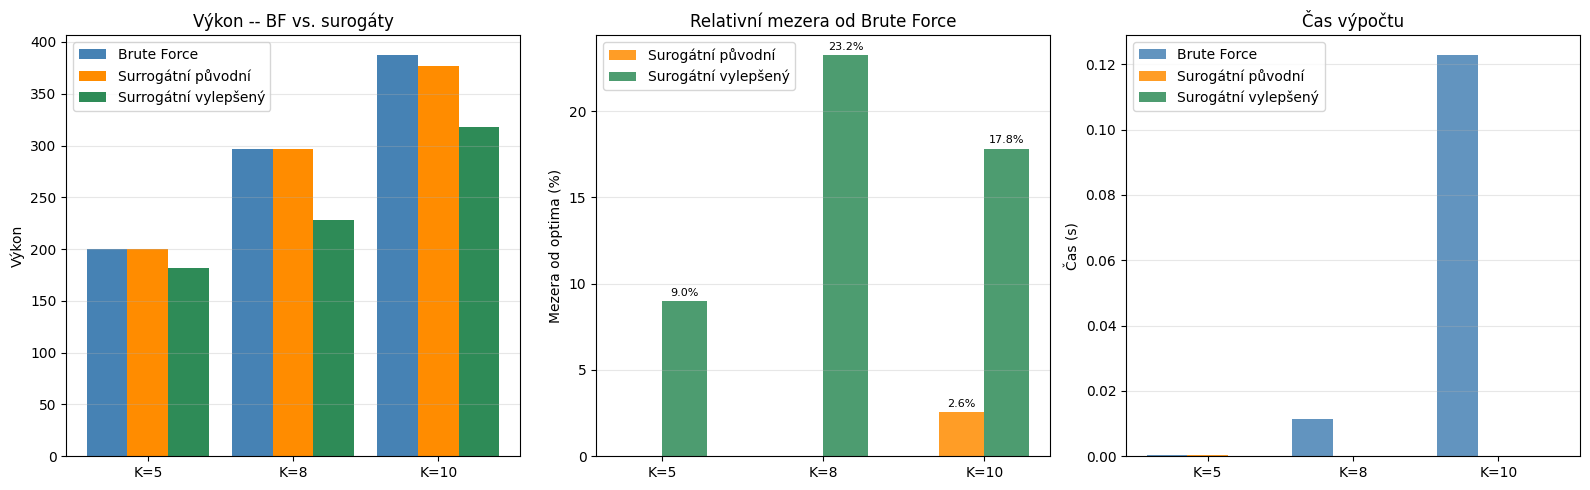

In [6]:
print("=== V. Srovnání přístupů ===\n")

comparison = []
for K_cmp in [5, 8, 10]:
    comp     = generate_components(K_cmp)
    W1c, W2c = limits(K_cmp)

    t0 = time.perf_counter()
    bf_sol, bf_pf, total_c, valid_c = brute_force(comp, K_cmp)
    bf_time = time.perf_counter() - t0

    smpls = sample_valid_solutions(comp, K_cmp, n=100, seed=7)

    t1     = time.perf_counter()
    surr_o = build_surrogate_original(smpls, K_cmp)
    sol_o  = greedy_by_surrogate(comp, K_cmp, surr_o)
    po, eo, pfo = evaluate(sol_o, comp)
    vo     = is_valid(po, eo, W1c, W2c)
    time_o = time.perf_counter() - t1

    t2     = time.perf_counter()
    surr_i = build_surrogate_improved(smpls, K_cmp, comp)
    sol_i  = greedy_surrogate_feasible(comp, K_cmp, surr_i)
    pi, ei, pfi = evaluate(sol_i, comp)
    vi     = is_valid(pi, ei, W1c, W2c)
    time_i = time.perf_counter() - t2

    gap_o = (bf_pf - pfo) / bf_pf * 100 if bf_pf > 0 and vo else float("nan")
    gap_i = (bf_pf - pfi) / bf_pf * 100 if bf_pf > 0 and vi else float("nan")

    comparison.append({
        "K": K_cmp, "total": total_c, "valid": valid_c,
        "bf_perf": bf_pf, "bf_time": bf_time,
        "so_perf": pfo, "so_valid": vo, "so_gap": gap_o, "so_time": time_o,
        "si_perf": pfi, "si_valid": vi, "si_gap": gap_i, "si_time": time_i,
    })

print(f"{'K':>3} | {'BF výkon':>9} | {'BF čas':>8} | "
      f"{'Sur. původní':>12} | {'Validní':>8} | {'Mezera':>8} | "
      f"{'Sur. vylepšený':>12} | {'Validní':>8} | {'Mezera':>8}")
print("-"*100)
for r in comparison:
    go = f"{r['so_gap']:.1f}%" if not np.isnan(r["so_gap"]) else "NEVALIDNÍ"
    gi = f"{r['si_gap']:.1f}%" if not np.isnan(r["si_gap"]) else "NEVALIDNÍ"
    print(f"{r['K']:>3} | {r['bf_perf']:>9} | {r['bf_time']:>7.4f}s | "
          f"{r['so_perf']:>12} | {str(r['so_valid']):>8} | {go:>8} | "
          f"{r['si_perf']:>12} | {str(r['si_valid']):>8} | {gi:>8}")

K_list   = [r["K"]       for r in comparison]
bf_perfs = [r["bf_perf"] for r in comparison]
so_perfs = [r["so_perf"] for r in comparison]
si_perfs = [r["si_perf"] for r in comparison]
gaps_o   = [r["so_gap"]  if not np.isnan(r["so_gap"]) else 0 for r in comparison]
gaps_i   = [r["si_gap"]  if not np.isnan(r["si_gap"]) else 0 for r in comparison]
bf_times = [r["bf_time"] for r in comparison]
so_times = [r["so_time"] for r in comparison]
si_times = [r["si_time"] for r in comparison]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(K_list))
w = 0.28

axes[0].bar(x-w, bf_perfs, w, label="Brute Force",       color="steelblue")
axes[0].bar(x,   so_perfs, w, label="Surrogátní původní",  color="darkorange")
axes[0].bar(x+w, si_perfs, w, label="Surrogátní vylepšený",color="seagreen")
for i, r in enumerate(comparison):
    if not r["so_valid"]: axes[0].text(x[i],   so_perfs[i]+2, "X", ha="center", color="red", fontsize=12, fontweight="bold")
    if not r["si_valid"]: axes[0].text(x[i]+w, si_perfs[i]+2, "X", ha="center", color="red", fontsize=12, fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"K={k}" for k in K_list])
axes[0].set_ylabel("Výkon"); axes[0].set_title("Výkon -- BF vs. surogáty")
axes[0].legend(); axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(x-w/2, gaps_o, w, label="Surogátní původní",  color="darkorange", alpha=0.85)
axes[1].bar(x+w/2, gaps_i, w, label="Surogátní vylepšený",color="seagreen",   alpha=0.85)
for i, (go, gi) in enumerate(zip(gaps_o, gaps_i)):
    if go > 0: axes[1].text(x[i]-w/2, go+0.3, f"{go:.1f}%", ha="center", fontsize=8)
    if gi > 0: axes[1].text(x[i]+w/2, gi+0.3, f"{gi:.1f}%", ha="center", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels([f"K={k}" for k in K_list])
axes[1].set_ylabel("Mezera od optima (%)"); axes[1].set_title("Relativní mezera od Brute Force")
axes[1].legend(); axes[1].grid(True, axis="y", alpha=0.3)

axes[2].bar(x-w, bf_times, w, label="Brute Force",       color="steelblue",  alpha=0.85)
axes[2].bar(x,   so_times, w, label="Surogátní původní",  color="darkorange", alpha=0.85)
axes[2].bar(x+w, si_times, w, label="Surogátní vylepšený",color="seagreen",   alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels([f"K={k}" for k in K_list])
axes[2].set_ylabel("Čas (s)"); axes[2].set_title("Čas výpočtu")
axes[2].legend(); axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## Komentář

**Nastavení experimentů:**
* **Komponenty:** $K \in \{5, 8, 10\}$, každá má 3 varianty s cenou 5–30, spotřebou 3–25 a výkonem 1–50 (zadáni uvádi "1-50" pro všechny hodnoty, ale s W1=20*K, W2=15*K by průměrný součet hodnot 1-50 (~25*K) vždy překročil oba limity, čímž by neexistovala žádná validní řešení. Proto jsou cena a spotřeba generovány v užších rozsazích, které zachovávají duch zadaní a zajišťují netriviálni podíl validních i nevalidních řešení.)
* **Omezení:** $W_1 = 20 \cdot K$ (cena), $W_2 = 15 \cdot K$ (spotřeba energie)
* **Vzorky pro surrogát:** 100 validních řešení
* **Surrogát původní:** průměrný výkon řešení obsahujících danou variantu
* **Surrogát vylepšený:** metrika $\text{výkon}/(\text{cena} + \text{spotřeba})$ průměrovaná přes vzorky s iterativní opravou validity

---

**1. Kolik řešení nesplňuje daná omezení?**

Přidání druhého omezení (spotřeba energie) výrazně snižuje podíl validních kombinací.
V provedených experimentech se pohybuje podíl nevalidních řešení kolem 55–70 % pro všechna K.
Obě omezení musejí být splněna současně, takže pravděpodobnost validity je přibližně součin
pravděpodobností splnění každého omezení zvlášť, což multiplikativně redukuje přípustný prostor.
Oproti jednomu omezení tedy přibude nevalidních řešení přibližně o faktor odpovídající podílu
kombinací, které by splňovaly cenu, ale ne spotřebu.

---

**2. Jak se změnila obtížnost oproti jednomu omezení?**

Se dvěma omezeními roste obtížnost dvojím způsobem. Zaprvé exaktní prohledávání prochází
stejný počet kombinací $3^K$, ale zahodí podstatně více z nich. Zadruhé vzorkování validních řešení pro surogát
je obtížnější: náhodné řešení splní obě omezení s nižší pravděpodobností, takže sběr
100 vzorků vyžaduje více pokusů. Při dalším přidávání omezení by tento efekt
dále eskaloval a vzorkování validního prostoru by se stávalo dominantní operací.

---

**3. Jaký je rozdíl v kvalitě řešení mezi exaktním a surogátním modelem?**

Původní surogát (průměrný výkon) dokáže pro normální data nalézt řešení v řádu
jednotek procent od optima a přitom zůstat validní. Jeho klíčový problém se projeví
na biased datasetu, kde vysoký výkon koreluje s vysokou cenou a spotřebou. Zde surogát
bez znalosti omezení konzistentně vybírá drahé varianty a výsledné řešení překračuje
oba limity. Optimalizuje správnou cílovou funkci (výkon), ale ignoruje přípustný prostor.
Vylepšený surogát s metrikou $\text{výkon}/(\text{cena} + \text{spotřeba})$ implicitně
penalizuje varianty náročné na zdroje a v kombinaci s opravou validity vždy vrátí
přípustné řešení, které je za cenu mírně vyšší mezery od optima oproti původnímu surogátu na
normálních datech.

---

**4. Pomohlo vylepšení surrogátu?**

Ano. Vylepšený surogát přináší dvě zlepšení. Metrika efektivity přirozeně upřednostňuje
varianty s dobrým poměrem výkonu k celkovým nárokům na zdroje, čímž vede k řešením
vzdáleným od hranic obou omezení. Iterativní oprava validity pak garantuje přípustnost
výsledku i v případech, kdy greedy výběr limity překračuje. Na biased datasetu,
kde původní surogát vracel nevalidní řešení, vylepšená verze nalezla validní řešení
podstatně blíže optimu než náhodný výběr. Klíčovým poznatkem je, že surogát musí
reflektovat strukturu omezení jinak optimalizuje špatný problém.
